### Built a customer intelligence model using RFM and K-Means clustering to identify high-value and at-risk customers and support data-driven marketing strategies.

Segment customers based on behavior and design growth strategy        The objective was to analyze retail transaction data to understand customer purchase behavior and segment customers based on value and engagement. This helps businesses design targeted marketing strategies and improve revenue

Customer analytics                                                   
*   Who spends most?
*   Who buys frequently?
*   Who stopped buying?
*   Who should get marketing campaigns?
*   Which customers generate revenue?









Import libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load dataset

In [9]:
from google.colab import files
uploaded = files.upload()


Saving OnlineRetail.csv to OnlineRetail.csv


In [60]:
rfm = pd.read_csv("rfm_data.csv")


In [61]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Dataset Structure

In [12]:
df.shape
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


DATA CLEANING

Remove rows without CustomerID

In [62]:
df = df.dropna(subset=['CustomerID'])


Remove cancelled orders

In [14]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


Remove negative quantity

In [15]:
df = df[df['Quantity'] > 0]


Remove negative price

In [16]:
df = df[df['UnitPrice'] > 0]


Check shape again

In [17]:
df.shape


(397884, 8)

Create Revenue Column                                                  


Revenue = Quantity × UnitPrice


Convert InvoiceDate to datetime

In [22]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


Check time range

In [23]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()


(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

RFM MODEL  
                                              
 Recency → last purchase
Frequency → number of purchases
Monetary → total spend

Define Snapshot Date

In [24]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


Create RFM Table

In [26]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']


In [27]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [28]:
rfm.describe()


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


RFM SCORING

In [29]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,4
12347.0,2,7,4310.00,4,4,4
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,3,1,4
12350.0,310,1,334.40,1,1,2


RFM Segment Code

In [30]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


Create Customer Segments

In [31]:
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4:
        return 'Champions'
    elif row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] == 4:
        return 'New Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Lost Customers
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,Loyal Customers
12349.0,19,1,1757.55,3,1,4,314,Lost Customers
12350.0,310,1,334.40,1,1,2,112,Lost Customers


Segment Distribution

In [32]:
rfm['Segment'].value_counts()


,count
Segment,
Lost Customers,1935
Loyal Customers,1560
Champions,609
New Customers,234


Revenue by Segment

In [33]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_revenue


,Monetary
Segment,
Champions,4578426.310
Loyal Customers,3063881.532
Lost Customers,981425.492
New Customers,287674.570


VISUALIZATION

Customer Segment Distribution

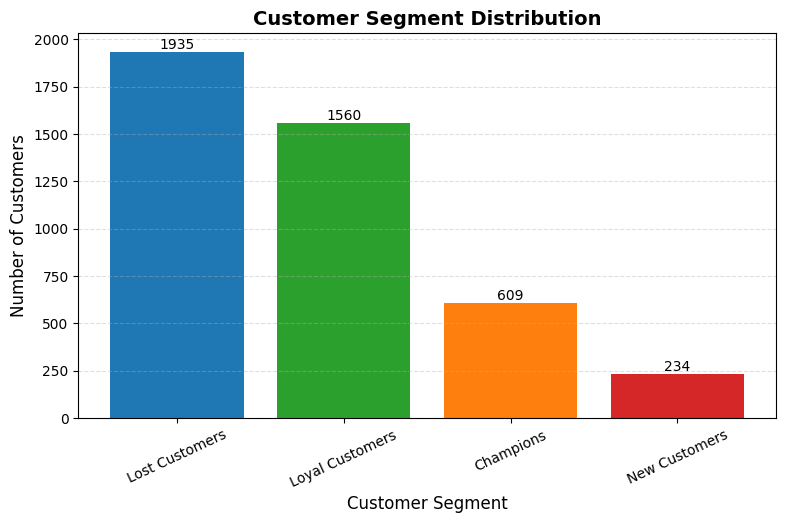

In [35]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(9,5))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values,
    color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']  # professional palette
)

plt.title("Customer Segment Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(rotation=25)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


Revenue by Segment

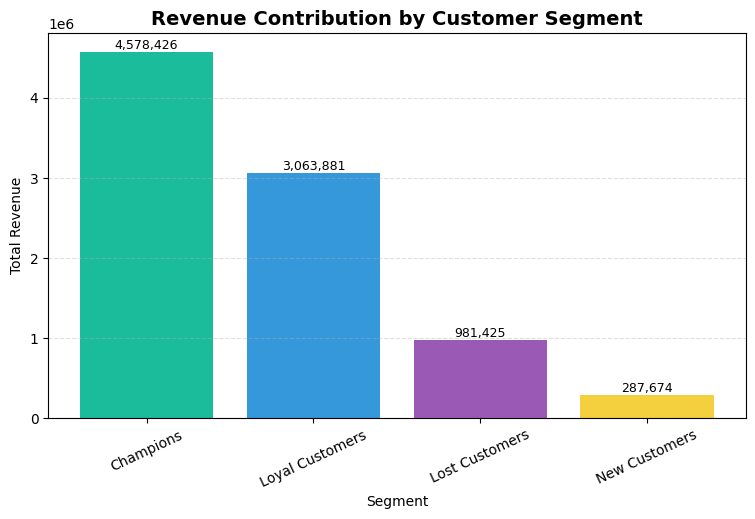

In [37]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    segment_revenue.index,
    segment_revenue.values,
    color=['#1ABC9C', '#3498DB', '#9B59B6', '#F4D03F']
)

plt.title("Revenue Contribution by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=25)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


Recency Distribution

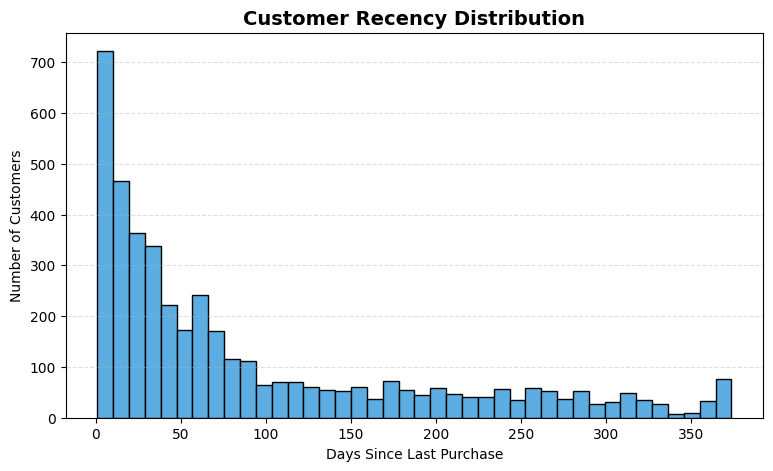

In [38]:
plt.figure(figsize=(9,5))

plt.hist(rfm['Recency'], bins=40, color='#5DADE2', edgecolor='black')

plt.title("Customer Recency Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


RFM Correlation Heatmap (Professional without seaborn)

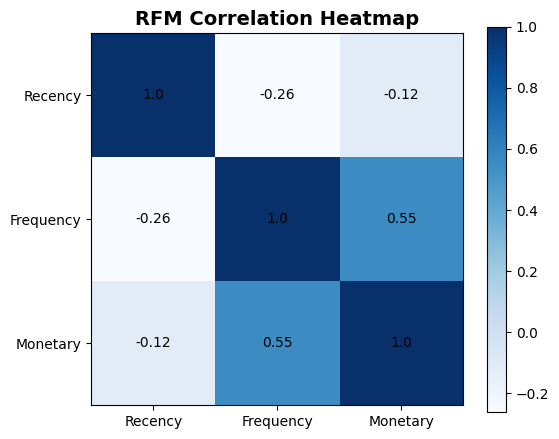

In [41]:
corr = rfm[['Recency','Frequency','Monetary']].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='Blues')

plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center', color='black')

plt.title("RFM Correlation Heatmap", fontsize=14, fontweight='bold')
plt.colorbar()
plt.show()


Correlation range:

+1 → strong positive relation (Customers who buy more frequently also spend more money.)

0 → no relation (Customers who purchased recently tend to buy more frequently.)

–1 → negative relation (Recent customers contribute more revenue.)



Loyal customers = high revenue

Recent customers = more engaged

Inactive customers = low revenue

Revenue Share Pie Chart

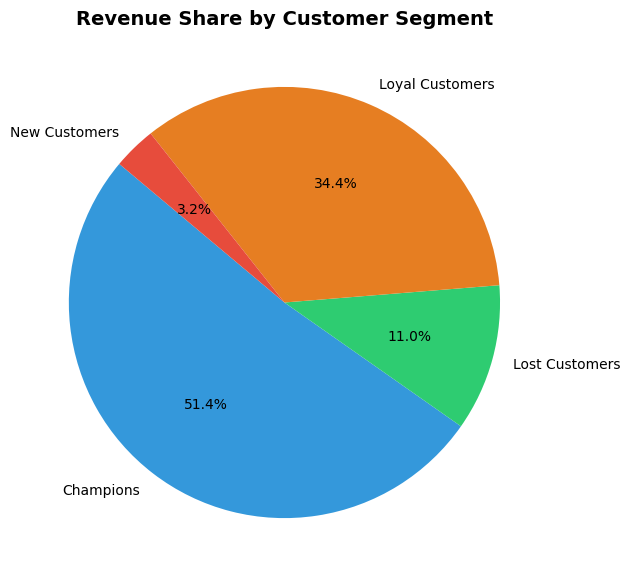

In [42]:
plt.figure(figsize=(7,7))

rfm.groupby('Segment')['Monetary'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#3498DB', '#2ECC71', '#E67E22', '#E74C3C'],
    startangle=140
)

plt.title("Revenue Share by Customer Segment", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.show()


K-Means clustering

Prepare Data for Clustering

In [43]:
from sklearn.preprocessing import StandardScaler

rfm_kmeans = rfm[['Recency','Frequency','Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_kmeans)


Find Optimal Number of Clusters (Elbow Method)

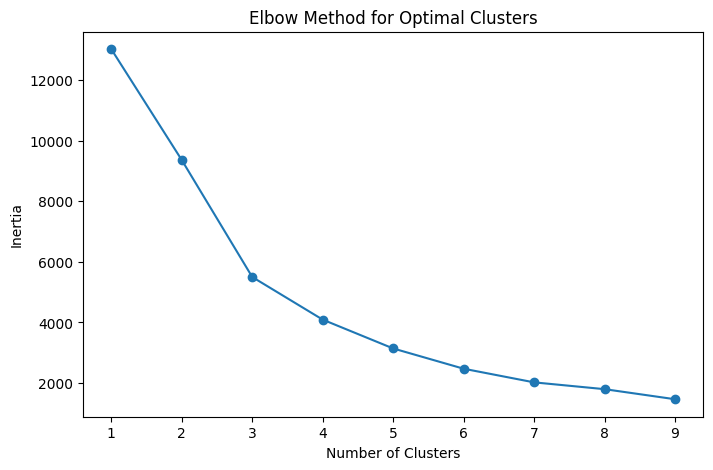

In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


Apply K-Means

In [45]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Cluster
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Lost Customers,3
12347.0,2,7,4310.00,4,4,4,444,Champions,0
12348.0,75,4,1797.24,2,3,4,234,Loyal Customers,0
12349.0,19,1,1757.55,3,1,4,314,Lost Customers,0
12350.0,310,1,334.40,1,1,2,112,Lost Customers,1


Clusters

In [46]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
cluster_summary


,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


If Cluster 0 has:

Low Recency
High Frequency
High Monetary

Then:
High Value Customers

If Cluster 2 has:
High Recency
Low Frequency
Low Monetary

Then:
Inactive Customers

Compare with RFM Segments

In [47]:
rfm.groupby(['Cluster','Segment']).size()


Cluster  Segment        
0        Champions           431
         Lost Customers     1035
         Loyal Customers    1355
         New Customers       233
1        Lost Customers      899
         Loyal Customers     168
2        Champions            10
         Loyal Customers       2
         New Customers         1
3        Champions           168
         Lost Customers        1
         Loyal Customers      35
dtype: int64

In [48]:
cluster_summary


,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


###Interpretation

K-Means clustering was applied on RFM features to identify natural customer groups based on purchasing behavior. The clustering revealed four major customer segments: inactive customers with low engagement, regular customers with moderate spending, high-value customers contributing significant revenue, and elite customers with extremely high purchase frequency and spending. The clustering results aligned strongly with RFM-based segmentation, validating customer behavior patterns. These insights enable targeted marketing strategies, customer retention programs, and personalized engagement approaches to drive revenue growth.

Analyzed retail transaction data and performed customer segmentation using RFM analysis and K-Means clustering. The analysis identified high-value, loyal, inactive, and elite customer groups based on purchase behavior. The project provided actionable insights for targeted marketing, retention strategies, and revenue optimization.